# 05 · K-Means and K-Means++

**Objectives:** cluster real customers with K-means, pick $k$ with the elbow method,
and see exactly why the *k-means++* initialisation scikit-learn uses by default beats
plain random initialisation.

K-means alternates two steps until convergence: assign every point to its nearest
centroid, then move each centroid to the mean of the points assigned to it. It always
converges — but only to a *local* optimum, and which one depends on where the
centroids started.

## 1. The goal: a few centres, small distances

Picture the 200 customers as dots on a plane, one axis for income and one for
spending score. Clustering asks for a few groups whose dots lie close together.
K-means turns "close together" into one number and makes it as small as it can.

**Notation.** The data are $n$ points $x_1, \dots, x_n$. Each $x_i$ is a vector of $d$
features, $x_i \in \mathbb{R}^d$. In the code the points are the rows of `X`, with
$n = 200$ and $d = 2$ (income in thousands of dollars, spending score from 1 to 100).
We choose a number of clusters $k$. Each cluster $C_j$ ($j = 1, \dots, k$) is a set
of points, and every point belongs to exactly one cluster. Each cluster has a
**centre** (or centroid) $\mu_j \in \mathbb{R}^d$, a point in the same space as the
data. The squared Euclidean distance between a point $x$ and a centre $\mu$ is

$$\lVert x - \mu \rVert^2 = \sum_{f=1}^{d} (x_f - \mu_f)^2 ,$$

the sum over the $d$ features of the squared coordinate differences.

**The objective.** K-means looks for the clusters and centres that make the total
squared distance from each point to its own centre as small as possible:

$$J = \sum_{j=1}^{k} \; \sum_{x \in C_j} \lVert x - \mu_j \rVert^2 .$$

Read it as: for each cluster, add up how far its points sit from its centre
(squared), then add over the clusters. $J$ is measured in squared feature units. A
small $J$ means tight, compact groups. $J$ is called the **inertia** or
within-cluster sum of squares; after fitting, scikit-learn stores it in `inertia_`.

Minimising $J$ exactly is hard: the number of ways to split $n$ points into $k$
groups grows roughly like $k^n$. So k-means improves one split step by step instead.

## 2. Lloyd's algorithm, and why it only goes downhill

$J$ depends on two things: the assignment (which cluster each point is in) and the
centres. Fixing either one makes the other easy to choose. **Lloyd's algorithm**
alternates the two choices:

1. **Assignment step.** Keep the centres fixed. Put each point in the cluster of its
   nearest centre.
2. **Update step.** Keep the assignment fixed. Move each centre to the mean of its
   points, $\mu_j = \frac{1}{\lvert C_j\rvert}\sum_{x\in C_j} x$, where $\lvert C_j\rvert$
   is the number of points in $C_j$.

Repeat until no point changes cluster.

**The assignment step cannot increase $J$.** $J$ has one term per point, its squared
distance to its centre. Choosing the nearest centre makes each term as small as the
current centres allow, so no term grows and neither does the sum.

**The update step cannot increase $J$.** With the assignment fixed, the clusters no
longer interact, so look at one cluster $C$ with $m$ points and ask which centre
$\mu$ minimises

$$g(\mu) = \sum_{x\in C} \lVert x - \mu\rVert^2 = \sum_{x \in C}\sum_{f=1}^d (x_f - \mu_f)^2 .$$

Differentiate with respect to one coordinate $\mu_f$. Only the terms containing
$\mu_f$ matter, and the derivative of $(x_f-\mu_f)^2$ is $-2(x_f-\mu_f)$:

$$\frac{\partial g}{\partial \mu_f} = -2\sum_{x\in C}(x_f - \mu_f) = -2\Big(\sum_{x\in C} x_f \;-\; m\,\mu_f\Big).$$

Setting this to zero gives $\mu_f = \frac1m \sum_{x\in C} x_f$: each coordinate of the
best centre is the average of that coordinate over the cluster. So the best centre
is the cluster mean, written $\bar x$. The second derivative is $2m > 0$, so this is a
minimum.

A second derivation shows *how much* a misplaced centre costs. Write
$x - \mu = (x - \bar x) + (\bar x - \mu)$ and expand the square. The cross terms add
up to zero because $\sum_{x\in C}(x-\bar x) = 0$, which leaves

$$\sum_{x\in C}\lVert x-\mu\rVert^2 = \sum_{x\in C}\lVert x-\bar x\rVert^2 + m\,\lVert \bar x - \mu\rVert^2 .$$

The first term does not depend on $\mu$. The second is a penalty: placing the centre
a distance $\delta$ away from the mean adds exactly $m\,\delta^2$. The mean is the only
choice with zero penalty.

**Convergence.** Each step lowers $J$ or leaves it unchanged, $J \ge 0$, and there are
only finitely many ways to assign $n$ points to $k$ clusters. So the algorithm stops
after a finite number of steps. It stops at a **local minimum**: no single step can
improve $J$, but a completely different split may have a lower $J$. Which local
minimum it reaches depends on the starting centres.

**Worked example.** Six points on a line, $x = 1, 2, 3, 8, 9, 12$, with $k = 2$ and a
poor start: $\mu_1 = 1$, $\mu_2 = 4$. The assignment step:

| $x$ | distance to $\mu_1 = 1$ | distance to $\mu_2 = 4$ | cluster | squared distance |
|---|---|---|---|---|
| 1 | 0 | 3 | 1 | 0 |
| 2 | 1 | 2 | 1 | 1 |
| 3 | 2 | 1 | 2 | 1 |
| 8 | 7 | 4 | 2 | 16 |
| 9 | 8 | 5 | 2 | 25 |
| 12 | 11 | 8 | 2 | 64 |

So $J = 0+1+1+16+25+64 = 107$. The update step moves the centres to the means:
$\mu_1 = (1+2)/2 = 1.5$ and $\mu_2 = (3+8+9+12)/4 = 8$. With the same clusters,
$J = (0.25+0.25) + (25+0+1+16) = 42.5$. That completes one iteration.

The next assignment step moves the point $3$ to cluster 1 (it is $1.5$ from $\mu_1$
and $5$ from $\mu_2$), and $J$ falls to $19.75$. The next update gives $\mu_1 = 2$,
$\mu_2 = 29/3 \approx 9.67$ and $J \approx 10.67$. After that no point changes cluster
and the algorithm stops. $J$ went $107 \to 42.5 \to 19.75 \to 10.67$ and never rose.

## 3. Better starting centres (k-means++), and choosing k

**Random initialisation** picks $k$ data points uniformly at random as the starting
centres. Two of them can fall inside the same natural group, and Lloyd's local moves
often cannot pull one of them out to a group that has no centre.

**k-means++** chooses the starting centres one at a time and favours points far from
the centres already chosen. Let $D(x)$ be the distance from a point $x$ to the
nearest centre chosen so far.

1. Pick the first centre uniformly at random from the data.
2. Pick the next centre at random, choosing point $x$ with probability
   $$P(x) = \frac{D(x)^2}{\sum_{x'} D(x')^2}.$$
3. Repeat step 2 until there are $k$ centres, then run Lloyd's algorithm from them.

A point next to a chosen centre has $D(x) \approx 0$ and is almost never picked; a
point in a region with no centre is likely to be picked.

With the six points above, suppose the first centre is $1$. Then
$D(x)^2 = 0, 1, 4, 49, 64, 121$, which add to $239$. The probability that the second
centre lands in the far group $\{8, 9, 12\}$ is $(49+64+121)/239 \approx 0.98$.
Uniform random choice among the five other points would give $3/5 = 0.6$.

The guarantee, proved by Arthur and Vassilvitskii (2007), concerns the seeding alone,
before any Lloyd step:

$$\mathbb{E}\big[J_{\text{k-means++}}\big] \le 8(\ln k + 2)\, J^{\ast},$$

where $J^\ast$ is the smallest inertia any $k$ centres can achieve and $\mathbb{E}$ is
the average over the random choices. The expected cost is within a factor
$O(\log k)$ of the best possible, and Lloyd's steps can only lower it further.
Random seeding has no bound of this kind: its $J$ can be arbitrarily worse than
$J^\ast$.

**Choosing $k$: the elbow.** Let $J^\ast(k)$ be the best inertia with $k$ clusters. It
never increases with $k$: given the best $k$-cluster solution, put one extra centre
exactly on a data point that is not yet a centre; that point's term drops to zero
and no other term grows. At $k = n$ every point is its own centre and $J = 0$. So
"minimise $J$ over $k$" always answers "as many clusters as points". Instead, plot $J$
against $k$ and look for the **elbow**. Before it, an extra centre separates groups
that were forced together, and $J$ drops a lot. After it, an extra centre only splits
a genuine group in two, and $J$ drops a little.

## 4. Feature scale, and a 2-D view with PCA

**Scale.** The distance $\lVert x-\mu\rVert^2 = \sum_f (x_f-\mu_f)^2$ adds squared
differences from every feature, in whatever units each feature has. A feature with a
large numerical spread dominates the sum. Suppose income were recorded in dollars
instead of thousands of dollars: a gap of 10 thousand dollars would contribute
$10000^2 = 10^8$, while the largest possible gap in spending score, from 1 to 99,
contributes only $98^2 = 9604$. K-means would then cluster on income alone. In this
data income and spending score have similar spreads (standard deviations of about
26 each), so the chapter clusters them as they are. When age is added (standard
deviation about 14 years), the three features are **standardised** first: each
feature $f$ is replaced by

$$z_f = \frac{x_f - m_f}{s_f},$$

where $m_f$ and $s_f$ are that feature's mean and standard deviation over the data.
Every standardised feature has mean 0 and standard deviation 1, so each gets a
comparable say in the distance. This is what `StandardScaler` does.

**PCA.** With three features the clusters can no longer be drawn directly.
Principal component analysis (PCA) finds the directions along which the data vary
most. Take the standardised points $z_i \in \mathbb{R}^d$ (mean zero) and a unit vector
$v$ ($\lVert v\rVert = 1$). Projecting each point onto $v$ gives the number $v^\top z_i$,
and the variance of these numbers is $v^\top \Sigma v$, where
$\Sigma = \frac1n\sum_i z_i z_i^\top$ is the $d\times d$ covariance matrix. To find the
direction of largest variance, maximise $v^\top\Sigma v$ subject to $v^\top v = 1$. With
a Lagrange multiplier $\lambda$, set the gradient of $v^\top\Sigma v - \lambda(v^\top v - 1)$
to zero:

$$2\Sigma v - 2\lambda v = 0 \quad\Longrightarrow\quad \Sigma v = \lambda v .$$

So the best direction is an eigenvector of $\Sigma$, and the variance along it is
$v^\top\Sigma v = \lambda v^\top v = \lambda$, its eigenvalue. The first principal
component is the eigenvector with the largest eigenvalue $\lambda_1$; the second is
the eigenvector with the next largest, $\lambda_2$, at right angles to the first. A
2-D plot on these two directions keeps the share
$(\lambda_1+\lambda_2)/(\lambda_1+\lambda_2+\lambda_3)$ of the total variance, which the
code prints from `explained_variance_ratio_`. PCA is only used for viewing here: the
clustering itself runs in the full 3-D space.

**In the code.** `KMeans(n_clusters=k, init="k-means++", n_init=10)` runs k-means++
seeding followed by Lloyd's algorithm 10 times and keeps the run with the lowest $J$.
After fitting, `km.cluster_centers_` holds the centres $\mu_j$, `km.labels_` each
point's cluster, and `km.inertia_` is $J$. Section 6 plots $J$ against $k$; section 7
compares `init="random"` with `init="k-means++"` using `n_init=1` (one Lloyd run
each); section 8 standardises three features and views the clusters through `PCA`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import mlutils
mlutils.set_style()

## 5. The data

200 mall customers: annual income and a spending score (1-100, assigned by the mall
from purchase behaviour). No labels — this is genuinely unsupervised, the classic
"segment our customers" problem.

In [2]:
mall = pd.read_csv("data/Mall_Customers.csv")
print(mall.shape)
mall.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


[Text(0.5, 0, 'Annual income (k$)'),
 Text(0, 0.5, 'Spending score (1-100)'),
 Text(0.5, 1.0, 'Mall customers')]

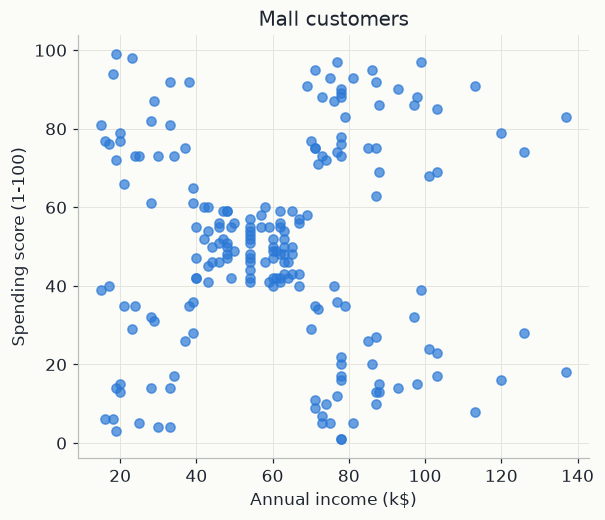

In [3]:
X = mall[["Annual Income (k$)", "Spending Score (1-100)"]].values
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], color=mlutils.BLUE, alpha=0.7)
ax.set(xlabel="Annual income (k$)", ylabel="Spending score (1-100)", title="Mall customers")

Even by eye there look to be a handful of natural groups: low income / low spending,
high income / high spending, high income / low spending, and so on. K-means turns
that visual impression into a rule.

## 6. Choosing k: the elbow method

K-means needs $k$ as an input. There's no single correct answer, but **inertia** —
the objective $J$ of section 1 — always
decreases as $k$ grows (section 3), so we look for where it stops decreasing *quickly*: the
"elbow".

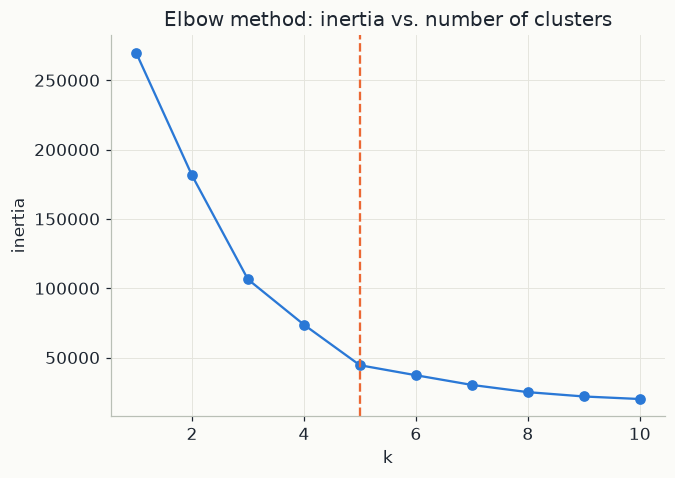

In [4]:
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(X).inertia_ for k in ks]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(list(ks), inertias, color=mlutils.BLUE, marker="o")
ax.set(xlabel="k", ylabel="inertia", title="Elbow method: inertia vs. number of clusters")
ax.axvline(5, color=mlutils.ORANGE, ls="--", lw=1.5)

The drop from $k{=}1$ to $k{=}5$ is steep; after that it flattens. $k=5$ is the
classic answer for this dataset, and it lines up with the visual groups above.

cluster
0    81
1    39
2    22
3    35
4    23
Name: customers, dtype: int64


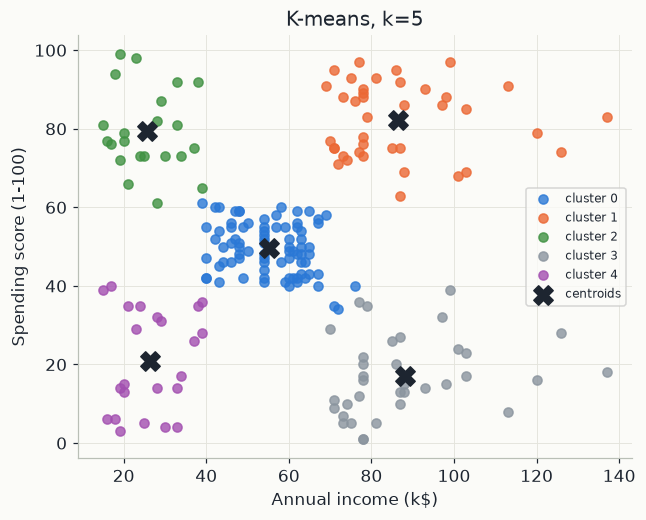

In [5]:
k = 5
km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(X)
mall["cluster"] = km.labels_
print(mall["cluster"].value_counts().sort_index().rename("customers"))

fig, ax = plt.subplots(figsize=(6.5, 5))
for c, color in zip(range(k), mlutils.PALETTE):
    sub = X[km.labels_ == c]
    ax.scatter(sub[:, 0], sub[:, 1], color=color, label=f"cluster {c}", alpha=0.8)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color=mlutils.INK, marker="X", s=160,
           label="centroids")
ax.set(xlabel="Annual income (k$)", ylabel="Spending score (1-100)", title=f"K-means, k={k}")
ax.legend(fontsize=8)

Five clean, interpretable segments fall out: budget-conscious high earners, careful
low earners, big spenders regardless of income, and so on — exactly the kind of
customer segments a marketing team would want to target differently.

## 7. Random init vs. k-means++

`init="random"` just picks $k$ data points at random as starting centroids: two
starting points can easily land close together, wasting a cluster and biasing where
K-means gets stuck. `init="k-means++"` instead picks starting centroids one at a
time, favouring points *far* from centroids already chosen — spreading the starting
guesses out before the iterating even begins.

We compare them fairly: **one single run each** (`n_init=1`, so neither method gets
to retry and keep its best attempt), repeated over 30 random seeds.

In [6]:
random_inertias, pp_inertias = [], []
for seed in range(30):
    random_inertias.append(
        KMeans(n_clusters=5, init="random", n_init=1, random_state=seed).fit(X).inertia_)
    pp_inertias.append(
        KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=seed).fit(X).inertia_)

random_inertias, pp_inertias = np.array(random_inertias), np.array(pp_inertias)
print(f"random init:   mean inertia {random_inertias.mean():,.0f}  "
      f"(std {random_inertias.std():,.0f}, worst {random_inertias.max():,.0f})")
print(f"k-means++ init: mean inertia {pp_inertias.mean():,.0f}  "
      f"(std {pp_inertias.std():,.0f}, worst {pp_inertias.max():,.0f})")

random init:   mean inertia 55,718  (std 14,855, worst 91,762)
k-means++ init: mean inertia 48,140  (std 8,250, worst 66,733)


[Text(0, 0.5, 'inertia (single run, no retries)'),
 Text(0.5, 1.0, '30 seeds: k-means++ wins on average and on worst case')]

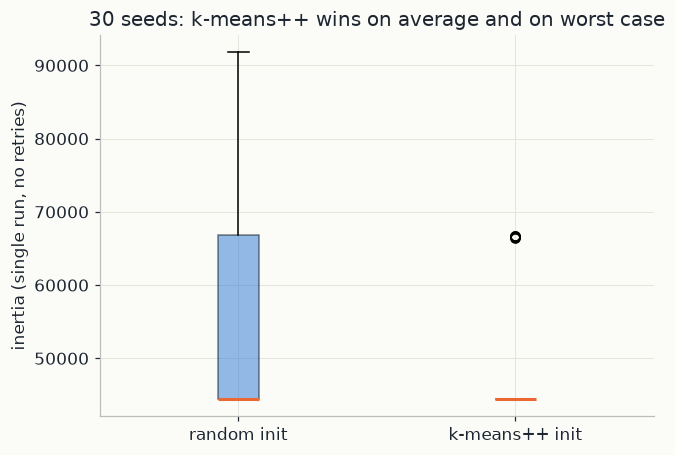

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.boxplot([random_inertias, pp_inertias], tick_labels=["random init", "k-means++ init"],
           patch_artist=True,
           boxprops=dict(facecolor=mlutils.BLUE, alpha=0.5),
           medianprops=dict(color=mlutils.ORANGE, linewidth=2))
ax.set(ylabel="inertia (single run, no retries)", title="30 seeds: k-means++ wins on average and on worst case")

k-means++ is both **better on average** and **more consistent** (smaller spread) than
random initialisation, and its worst run across 30 seeds still beats random
initialisation's *average* run. That's exactly why scikit-learn defaults to it, and
why real code should almost never override that default.

## 8. A 2D view via PCA

The plots above already used income and spending directly because there were only two
features. With more features (say, if we clustered on income, spending *and* age),
we'd need to project down to 2D to plot anything — principal component analysis (PCA)
does that by finding the directions of largest variance.

variance explained by the first 2 components: 77.6%


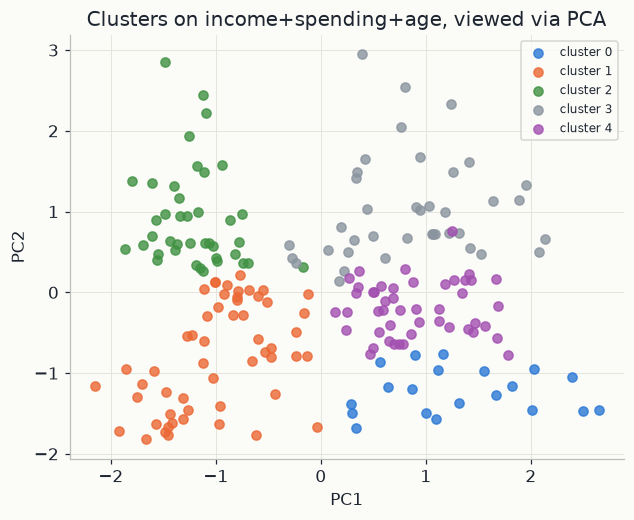

In [8]:
X3 = StandardScaler().fit_transform(mall[["Annual Income (k$)", "Spending Score (1-100)", "Age"]])
pca = PCA(n_components=2).fit(X3)
X3_2d = pca.transform(X3)
print(f"variance explained by the first 2 components: {pca.explained_variance_ratio_.sum():.1%}")

km3 = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42).fit(X3)
fig, ax = plt.subplots(figsize=(6.5, 5))
for c, color in zip(range(5), mlutils.PALETTE):
    sub = X3_2d[km3.labels_ == c]
    ax.scatter(sub[:, 0], sub[:, 1], color=color, label=f"cluster {c}", alpha=0.8)
ax.set(xlabel="PC1", ylabel="PC2", title="Clusters on income+spending+age, viewed via PCA")
ax.legend(fontsize=8)

Adding `Age` changes which customers land together (PCA chapter 05's clusters aren't
the same groups as the 2-feature clustering above), but the plot lets us see the
result of clustering in more than 2 dimensions at all — that's PCA's job here, not
K-means's.

## Exercises

### Exercise 1: `n_init` in practice
Refit with `init="random", n_init=10` (the scikit-learn old default: retry 10 times,
keep the best). How does its inertia compare to a single k-means++ run? To 10 retries
of k-means++?

<details><summary>Solution</summary>

```python
KMeans(n_clusters=5, init="random", n_init=10, random_state=0).fit(X).inertia_
```
Multiple restarts substantially close the gap — the whole risk of random init is a
single *unlucky* draw, which retries mostly cure. K-means++ still wins because it
also converges to good solutions *faster* per attempt.
</details>

### Exercise 2: Silhouette score
Compute `sklearn.metrics.silhouette_score` for $k=2 \ldots 8$ instead of inertia. Does
it pick the same $k$ as the elbow method?

<details><summary>Solution</summary>

```python
from sklearn.metrics import silhouette_score
for k in range(2, 9):
    labels = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit_predict(X)
    print(k, silhouette_score(X, labels))
```
Silhouette score often agrees closely with the elbow's choice, but unlike inertia it
doesn't automatically favour larger $k$, so it's a useful second opinion.
</details>

## Key takeaways

- K-means alternates "assign to nearest centroid" and "move centroid to the mean of
  its points" until neither changes; it always converges, but only to a local
  optimum.
- The elbow method picks $k$ by looking for where adding another cluster stops buying
  much reduction in inertia.
- k-means++ initialisation spreads out the starting centroids instead of picking them
  purely at random, giving both a better *and* more consistent result across runs —
  which is why it's the library default.